In [69]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [70]:
df = pd.read_csv("Netflix Dataset.csv")

df.head()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [71]:
# Understand Data

In [72]:
df.shape

(7789, 11)

In [73]:
df.columns

Index(['Show_Id', 'Category', 'Title', 'Director', 'Cast', 'Country',
       'Release_Date', 'Rating', 'Duration', 'Type', 'Description'],
      dtype='object')

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Show_Id       7789 non-null   object
 1   Category      7789 non-null   object
 2   Title         7789 non-null   object
 3   Director      5401 non-null   object
 4   Cast          7071 non-null   object
 5   Country       7282 non-null   object
 6   Release_Date  7779 non-null   object
 7   Rating        7782 non-null   object
 8   Duration      7789 non-null   object
 9   Type          7789 non-null   object
 10  Description   7789 non-null   object
dtypes: object(11)
memory usage: 669.5+ KB


In [75]:
df.isnull().sum()

,0
Show_Id,0
Category,0
Title,0
Director,2388
Cast,718
Country,507
Release_Date,10
Rating,7
Duration,0
Type,0


In [76]:
# Data Cleaning

In [77]:
# Release_Date in text to date format
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')


In [78]:

# Creating year column
df['Year'] = df['Release_Date'].dt.year

In [79]:
# Replace year and convert decimal to integer
df = df.dropna(subset=['Year'])
df['Year'] = df['Year'].astype(int)  # 2019.0 → 2019

In [80]:
# Managing null column of rating and country
df['Rating']  = df['Rating'].fillna('Not Rated')
df['Country'] = df['Country'].fillna('Unknown')

In [81]:
# Content Type Column
df['Content_Type'] = df['Type'].apply(
    lambda x: 'TV Show' if 'TV Show' in str(x) else 'Movie'
)

In [82]:
#  Duration Parsing

In [83]:
# Creating parsde duration to hande both min and season

def parse_duration(d):
    d = str(d)
    if 'Season' in d:
        return int(d.split()[0]), 'Seasons'   # "2 Seasons" → 2, "Seasons"
    elif 'min' in d:
        return int(d.replace('min','').strip()), 'Minutes'  # "93 min" → 93, "Minutes"
    return np.nan, 'Unknown'

# Function calling in each row
df[['Duration_Val', 'Duration_Unit']] = pd.DataFrame(
    df['Duration'].apply(parse_duration).tolist(), index=df.index
)

In [84]:
# Explode

In [85]:
# there are multiple value in country column which have to be treated dintinctly
df_country = (
    df.assign(Country = df['Country'].str.split(','))  # Step 1: split → list
      .explode('Country')                               # Step 2: list → alag rows
      .assign(Country = lambda x: x['Country'].str.strip())  # Step 3: spaces hatao
)

In [86]:
# Aggregations

In [87]:
# No. of movies and tv show in a year
by_year_type = df.groupby(['Year', 'Content_Type']).size().unstack(fill_value=0)

In [88]:
by_year_type

Content_Type,Movie,TV Show
Year,,
2008,2,0
2009,2,0
2010,1,0
2011,13,0
2012,3,0
2013,8,2
2014,23,1
2015,69,10
2016,316,116


In [89]:
# Top 10 genre
df_genre = (
    df.assign(Genre = df['Type'].str.split(','))  # Step 1: split 'Type' to list
      .explode('Genre')                               # Step 2: explode list to new rows
      .assign(Genre = lambda x: x['Genre'].str.strip())  # Step 3: strip spaces
)
top_genres = df_genre['Genre'].value_counts().head(10)

In [90]:
# Every year movie percentage
movie_pct = by_year_type['Movie'] / by_year_type.sum(axis=1) * 100

In [91]:
#  Charts (Matplotlib)

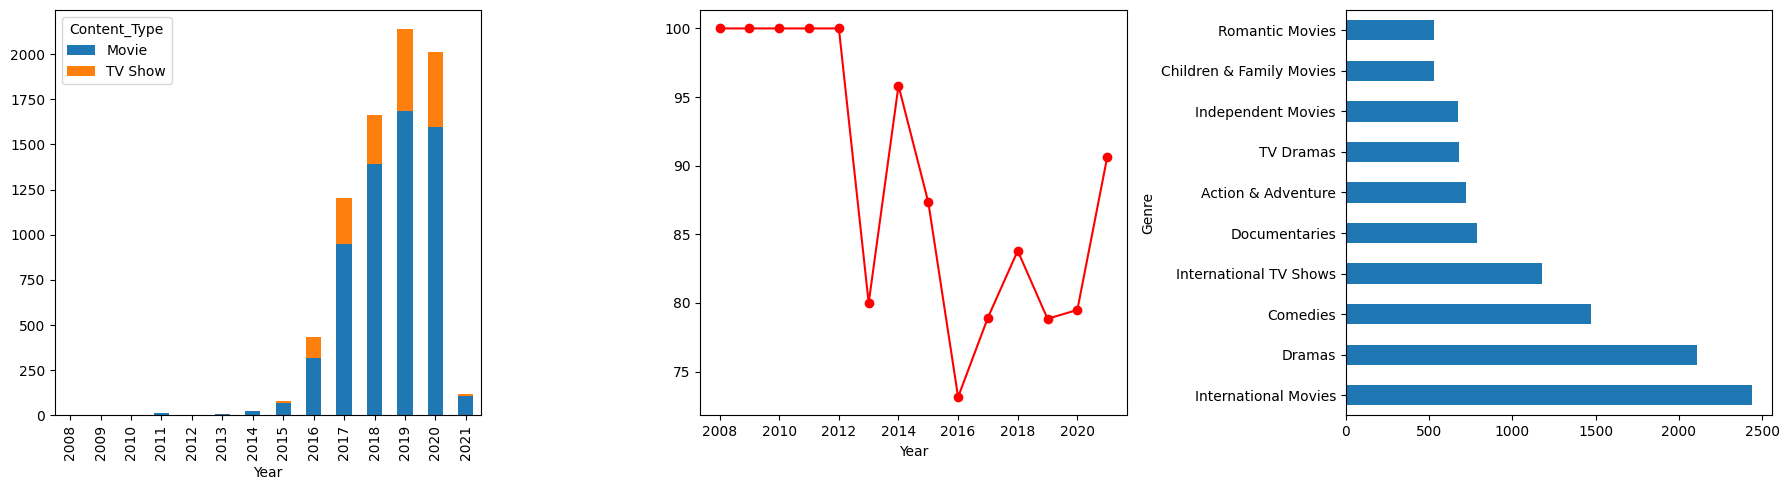

In [92]:
# 6 charts together
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
#            ↑ 2 rows, 3 columns ka grid

# Chart 1 — Stacked bar
by_year_type.plot(kind='bar', stacked=True, ax=axes[0])

# Chart 2 — Line chart
movie_pct.plot(ax=axes[1], marker='o', color='red')

# Chart 3 — Horizontal bar
top_genres.plot(kind='barh', ax=axes[2])

# all chart saved
plt.tight_layout()   # overlap problem
plt.savefig('netflix_dashboard.png', dpi=200)
plt.show()